In [17]:
import geopandas as gpd
import osmnx as ox
from shapely.geometry import Polygon
import matplotlib.pyplot as plt

In [26]:
# Coordinates for the area of interest
coords = [
    (11.329506845549249, 44.49032812319622),
    (11.326974840312921, 44.4990525931436),
    (11.339591951151563, 44.505602740642026),
    (11.348432512272106, 44.50407239822306),
    (11.356071443324074, 44.50101159288372),
    (11.35804554907656, 44.48567453868279),
    (11.356243104671039, 44.484449849517645),
    (11.339549036248483, 44.486439956354516),
    (11.329506845549249, 44.49032812319622)
]

custom_polygon = Polygon(coords)

# Convert the polygon into a GeoDataFrame
custom_polygon_gdf = gpd.GeoDataFrame(index=[0], crs="EPSG:4326", geometry=[custom_polygon])

In [44]:
# Download the map of Bologna
bologna = ox.geocode_to_gdf("Bologna, Italy")

# Clip the Bologna map to the custom polygon
bologna_inside_custom_polygon = gpd.clip(bologna, custom_polygon_gdf)

bologna_gdf = gpd.read_file("data/bologna_map.geojson")

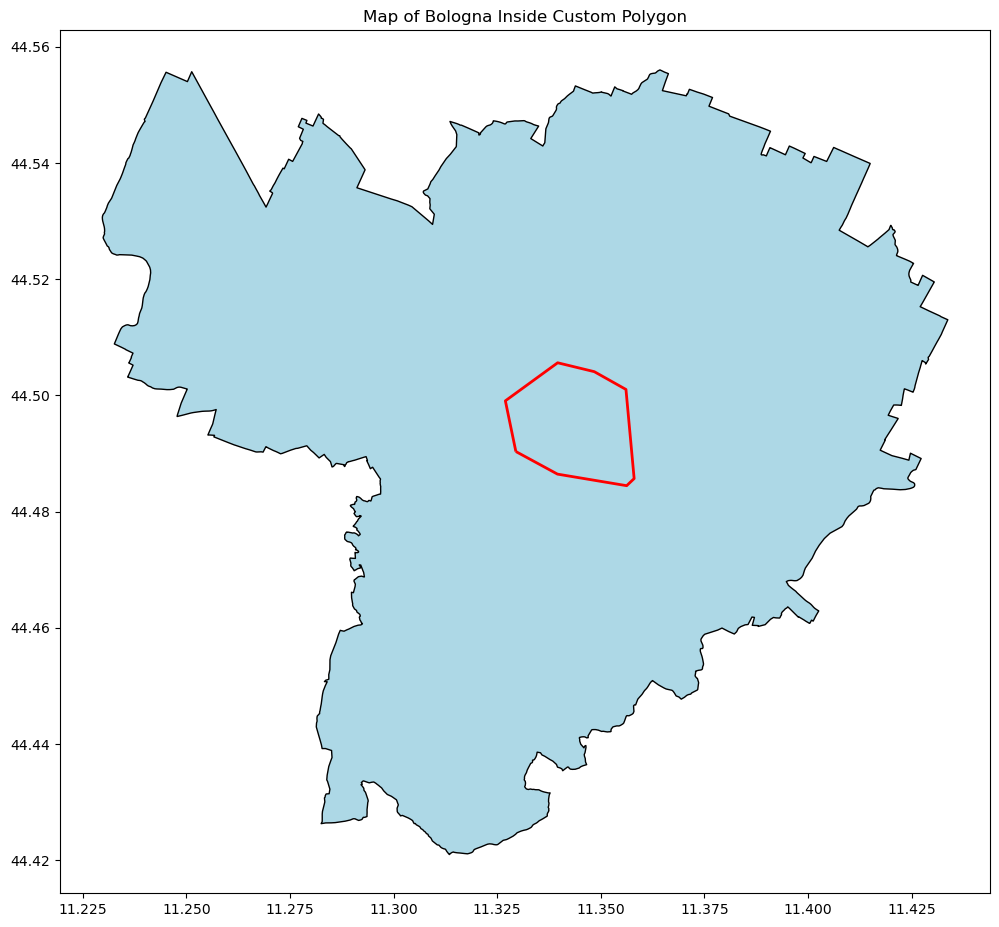

In [45]:
# Save the clipped map as a GeoJSON file
bologna_inside_custom_polygon.to_file("data/bologna_inside_custom_polygon.geojson", driver="GeoJSON")

# Plot the map
fig, ax = plt.subplots(1, 1, figsize=(12, 12))
bologna_gdf.plot(ax=ax, color="lightblue", edgecolor="black", figsize=(10, 10))
custom_polygon_gdf.plot(ax=ax, facecolor='none', edgecolor='red', linewidth=2, label='Custom Polygon')
plt.title("Map of Bologna Inside Custom Polygon")
plt.show()

In [59]:
# Add this as a new cell

import pandas as pd
from shapely.geometry import Point

# Load school data
schools_df = pd.read_csv("data/elenco-delle-scuole.csv", delimiter=";")
print(f"Initial rows loaded: {len(schools_df)}") # <-- ADD THIS
# Function to parse coordinates from 'Geo Point'
def parse_coords(geo_point_str):
    try:
        lat_str, lon_str = geo_point_str.split(',')
        return float(lon_str.strip()), float(lat_str.strip()) # Return (longitude, latitude)
    except (ValueError, AttributeError):
        return None, None

# Apply the function to create longitude and latitude columns
schools_df['longitude'], schools_df['latitude'] = zip(*schools_df['Geo Point'].apply(parse_coords))

# Drop rows where coordinates couldn't be parsed
schools_df.dropna(subset=['longitude', 'latitude'], inplace=True)
print(f"Rows after dropping invalid coordinates: {len(schools_df)}") # <-- ADD THIS
# Create Point geometries
geometry = [Point(xy) for xy in zip(schools_df['longitude'], schools_df['latitude'])]

# Create GeoDataFrame for schools
schools_gdf = gpd.GeoDataFrame(schools_df, geometry=geometry, crs="EPSG:4326")

# Filter schools within the custom polygon (using the previously defined custom_polygon_gdf)
schools_inside_custom_polygon = gpd.sjoin(schools_gdf, custom_polygon_gdf, how="inner", predicate='within')

print(f"Found {len(schools_inside_custom_polygon)} schools within the custom polygon.")
print(f"Number of unique CIVKEYs in schools_gdf: {schools_gdf['CIVKEY'].nunique()}")

Initial rows loaded: 58
Rows after dropping invalid coordinates: 58
Found 58 schools within the custom polygon.
Number of unique CIVKEYs in schools_gdf: 47


In [40]:
# Load porte data
porte_df = pd.read_csv("data/porte.csv")

# Create Point geometries (Longitude, Latitude)
porte_geometry = [Point(xy) for xy in zip(porte_df['Longitude'], porte_df['Latitude'])]

# Create GeoDataFrame for porte
porte_gdf = gpd.GeoDataFrame(porte_df, geometry=porte_geometry, crs="EPSG:4326")

# Optional: Filter porte within the custom polygon (if needed, though they likely are)
# porte_inside_custom_polygon = gpd.sjoin(porte_gdf, custom_polygon_gdf, how="inner", predicate='within')
# print(f"Found {len(porte_inside_custom_polygon)} porte within the custom polygon.")
# Use porte_gdf directly if filtering isn't strictly necessary for this dataset

print(f"Loaded {len(porte_gdf)} porte locations.")

Loaded 9 porte locations.


In [88]:
# Add this as a new cell

from shapely.geometry import Point # Make sure Point is imported
import json # Import json module
import warnings
import pandas as pd # Make sure pandas is imported
import geopandas as gpd # Make sure geopandas is imported

# Load park data - Adjust delimiter if necessary (e.g., delimiter=';')
# Removed the try-except block for FileNotFoundError as requested
parks_df = pd.read_csv("data/carta-tecnica-comunale-toponimi-parchi-e-giardini.csv", sep=";")
print(f"Loaded {len(parks_df)} park entries.")

parks_gdf = None
parks_inside_custom_polygon = gpd.GeoDataFrame() # Initialize empty GeoDataFrame

if parks_df is not None: # Keep check in case loading failed for other reasons (though unlikely without try-except)
    geom_col_name = 'Geo Shape' # Directly use the correct column name

    if geom_col_name in parks_df.columns:
        print(f"DEBUG: Using geometry column: {geom_col_name}")
        try:
            # Function to parse GeoJSON string and create Point
            def parse_geojson_point(geojson_str):
                try:
                    if pd.isna(geojson_str) or not isinstance(geojson_str, str):
                        return None
                    # Parse the JSON string
                    geom_data = json.loads(geojson_str)
                    # Check if it's a Point and extract coordinates (lon, lat)
                    if geom_data.get('type') == 'Point':
                        coords = geom_data.get('coordinates')
                        if coords and len(coords) == 2:
                            # Ensure coordinates are float (lon, lat)
                            return Point(float(coords[0]), float(coords[1]))
                    return None
                except (json.JSONDecodeError, TypeError, ValueError):
                    return None

            # Apply the parsing function
            parks_df['geometry'] = parks_df[geom_col_name].apply(parse_geojson_point)

            # Drop rows where geometry couldn't be parsed
            parks_df.dropna(subset=['geometry'], inplace=True)
            print(f"Rows after geometry parsing: {len(parks_df)}")

            if not parks_df.empty:
                # Create GeoDataFrame - Assuming EPSG:4326
                parks_gdf = gpd.GeoDataFrame(parks_df, geometry='geometry', crs="EPSG:4326")
                print(f"Created GeoDataFrame with {len(parks_gdf)} park points.")

                # Ensure CRS match before spatial join (clip not suitable for points vs polygon)
                if parks_gdf.crs != custom_polygon_gdf.crs:
                    print(f"Warning: Park CRS ({parks_gdf.crs}) differs from polygon CRS ({custom_polygon_gdf.crs}). Attempting to reproject parks.")
                    try:
                        parks_gdf = parks_gdf.to_crs(custom_polygon_gdf.crs)
                    except Exception as e:
                        print(f"Error reprojecting parks: {e}. Skipping park filtering.")
                        parks_gdf = None

                if parks_gdf is not None:
                    # Filter parks within the custom polygon using spatial join
                    parks_inside_custom_polygon = gpd.sjoin(parks_gdf, custom_polygon_gdf, how="inner", predicate='within')
                    print(f"Found {len(parks_inside_custom_polygon)} park points within the custom polygon.")
            else:
                 print("No valid park geometries found after parsing.")

        except Exception as e:
            print(f"Error processing park geometries: {e}. Skipping park layer.")
            parks_gdf = None
    else:
        print(f"Could not find the geometry column '{geom_col_name}' in the park CSV. Skipping park layer.")
        print(f"DEBUG: Actual columns found: {parks_df.columns.to_list()}")
        parks_gdf = None

Loaded 23 park entries.
DEBUG: Using geometry column: Geo Shape
Rows after geometry parsing: 23
Created GeoDataFrame with 23 park points.
Found 23 park points within the custom polygon.


/var/folders/36/h9ntx1qx07ncdrcnhkyd0cd40000gn/T/ipykernel_49672/1920774860.py:17: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()


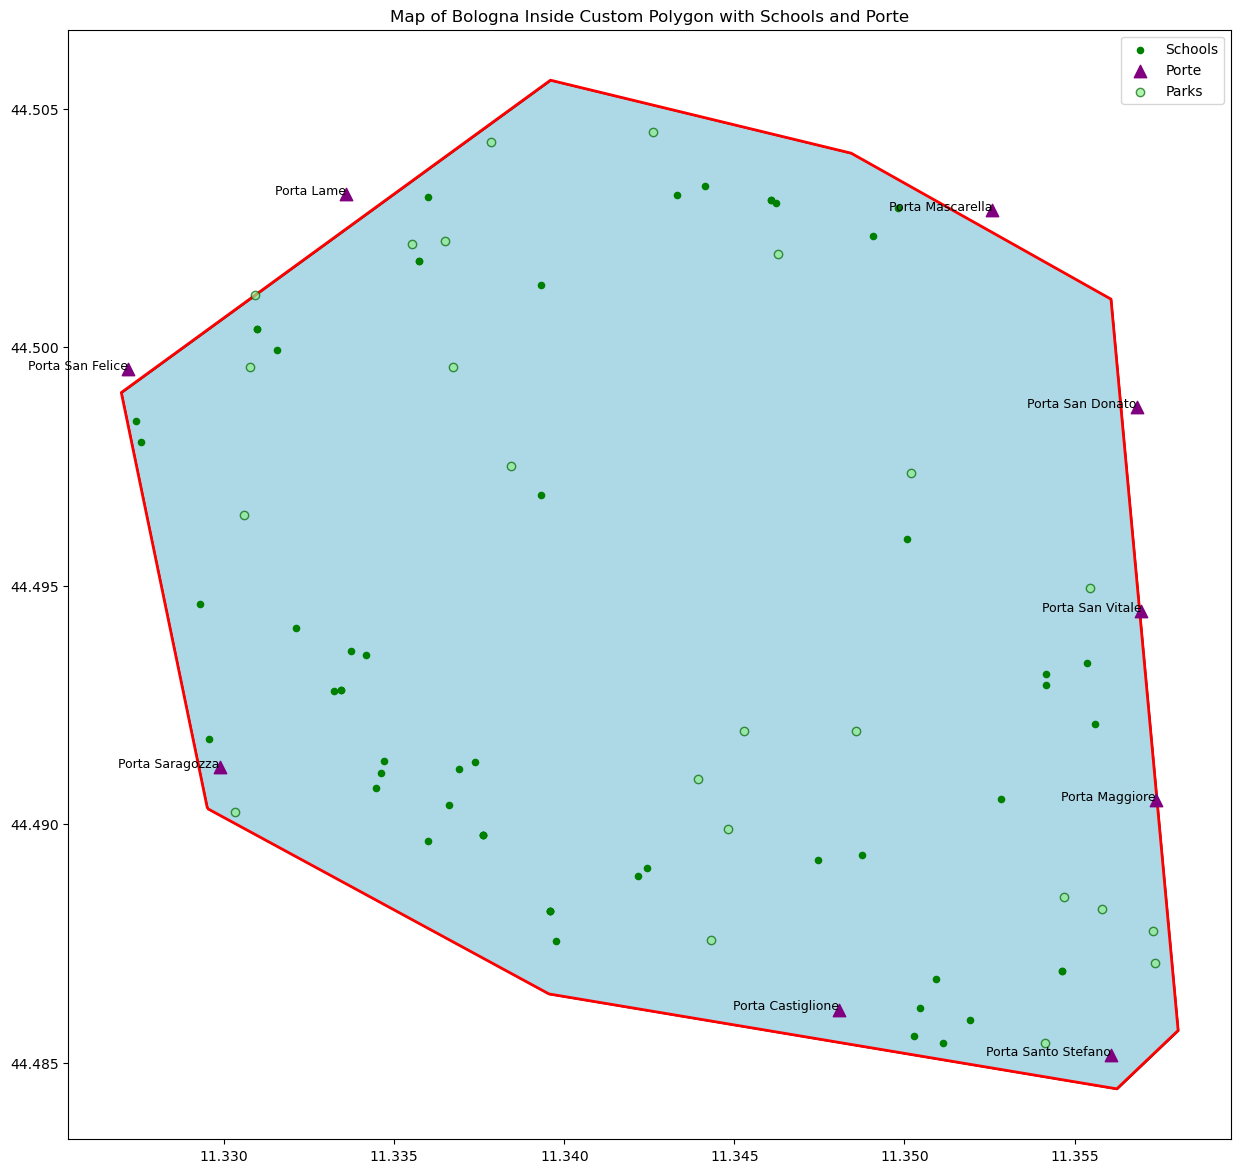

In [89]:
# Save the clipped map as a GeoJSON file
bologna_inside_custom_polygon.to_file("data/bologna_inside_custom_polygon.geojson", driver="GeoJSON")

# Plot the map
fig, ax = plt.subplots(1, 1, figsize=(15, 15))
bologna_inside_custom_polygon.plot(ax=ax, color="lightblue", edgecolor="black", label='Bologna Area'),
custom_polygon_gdf.plot(ax=ax, facecolor='none', edgecolor='red', linewidth=2, label='Custom Polygon')
schools_inside_custom_polygon.plot(ax=ax, marker='o', color='green', markersize=20, label='Schools')
porte_gdf.plot(ax=ax, marker='^', color='purple', markersize=80, label='Porte')
parks_inside_custom_polygon.plot(ax=ax, color='lightgreen', edgecolor='darkgreen', alpha=0.7, label='Parks', zorder=2)

# Add labels for porte names
for x, y, label in zip(porte_gdf.geometry.x, porte_gdf.geometry.y, porte_gdf['Name']):
                    ax.text(x, y, label, fontsize=9, ha='right') # Adjust fontsize and alignment as needed

plt.title("Map of Bologna Inside Custom Polygon with Schools and Porte")
plt.legend()
plt.show()

In [67]:
# Add this as a new cell

# Define the range (buffer distance in meters)
buffer_distance = 650 # e.g., 500 meters

# --- Ensure schools_gdf and porte_gdf are loaded and have the correct CRS (EPSG:4326) ---
# (This should be done in previous cells, like 4700e0b0 and 90f0ac6c)
# Make sure schools_gdf is created before this cell runs

# Choose a suitable projected CRS for Bologna (UTM Zone 32N)
projected_crs = "EPSG:32632"

# Project both GeoDataFrames
schools_proj = schools_gdf.to_crs(projected_crs)
porte_proj = porte_gdf.to_crs(projected_crs)

# Create buffer zones around each porta
porte_buffers = porte_proj.geometry.buffer(buffer_distance)

# Create a GeoDataFrame for the buffers, keeping the Porte names
porte_buffer_gdf = gpd.GeoDataFrame(geometry=porte_buffers, crs=projected_crs)
porte_buffer_gdf['Porta_Name'] = porte_proj['Name'].values # Add names for joining

# Perform a spatial join to find schools within the buffers
# 'predicate="within"' finds schools whose points are within the buffer polygons
schools_near_porte = gpd.sjoin(schools_proj, porte_buffer_gdf, how="inner", predicate="within")

# --- Process and display the results ---

# Project back to EPSG:4326 if needed for plotting with original data
# schools_near_porte = schools_near_porte.to_crs("EPSG:4326")

# Print the results
print(f"Schools found within {buffer_distance}m of each Porta:")
if not schools_near_porte.empty:
    # Group by Porta name and list the schools
    schools_by_porta = schools_near_porte.groupby('Porta_Name')['NOME'].apply(list)
    for porta_name, school_list in schools_by_porta.items():
        print(f"\n--- {porta_name} ---")
        if school_list:
            for school_name in school_list:
                print(f"- {school_name}")
        else:
            print("  (No schools found in range)")
else:
    print("No schools found within the specified range of any Porta.")

# Print the total count of school services found near any porta
# Note: A service might be counted multiple times if near multiple portes, use unique index count
unique_near_porta_indices = schools_near_porte.index.unique() # Get unique indices of rows near portes
count_near_porte_services = len(unique_near_porta_indices)
print(f"\nTotal number of unique school services found within {buffer_distance}m of any Porta: {count_near_porte_services}")

# --- Calculate school services outside the buffer zones ---
all_school_indices = set(schools_gdf.index)
near_porta_indices = set(unique_near_porta_indices) # Use the unique indices found above

# Find the difference: Indices in all_school_indices but not in near_porta_indices
outside_school_indices = all_school_indices - near_porta_indices
count_outside_services = len(outside_school_indices)

print(f"\nTotal number of school services in the original dataset: {len(all_school_indices)}")
print(f"Number of school services located outside the {buffer_distance}m range of all Porte: {count_outside_services}")

# Optional: You can now use 'schools_near_porte' GeoDataFrame for further analysis or plotting
# For example, to plot only the schools near Porta Saragozza:
# schools_near_saragozza = schools_near_porte[schools_near_porte['Porta_Name'] == 'Porta Saragozza']
# fig, ax = plt.subplots()
# porte_buffer_gdf[porte_buffer_gdf['Porta_Name'] == 'Porta Saragozza'].plot(ax=ax, alpha=0.5)
# schools_near_saragozza.plot(ax=ax, color='red')
# plt.show()

# Calculate the number of repetitions (services near multiple portes)",
total_matches = len(schools_near_porte)
total_repetitions = total_matches - count_near_porte_services
print(f"\nTotal number of matches (school service within a porta buffer): {total_matches}")
print(f"Number of times school services were counted multiple times (due to being near >1 Porta): {total_repetitions}")

# Optional: You can now use 'schools_near_porte' GeoDataFrame for further analysis or plotting
# For example, to plot only the schools near Porta Saragozza:

Schools found within 650m of each Porta:

--- Porta Castiglione ---
- TOVAGLIE
- EDUCARE E CRESCERE
- GALVANI (SEDE CENTRALE)
- ARCANGELI - CENTRO DIDATTICA DELLE ARTI (2006)
- ROLANDINO DE PASSEGGERI
- LA TORTA IN CIELO
- CARDUCCI
- PADIGLIONE
- SAN PIETRO MARTIRE
- GOZZADINI
- CARDUCCI
- BARACCANO

--- Porta Lame ---
- ALDROVANDI RUBBIANI (SEDE CENTRALE)
- MAGO MERLINO
- VIGANÒ
- GALVANI (SEDE DISTACCATA)
- GANDINO
- GUIDI
- GUIDI

--- Porta Maggiore ---
- EDUCARE E CRESCERE
- GUIDO RENI
- IL GIARDINO SEGRETO
- LAURA BASSI (SEDE DISTACCATA)
- CARDUCCI
- CARDUCCI
- ZAMBONI

--- Porta Mascarella ---
- GIACCAGLIA BETTI
- ERCOLANI
- BETTI - PLESSO 2
- BETTI - PLESSO 3
- IRNERIO

--- Porta San Donato ---
- LAURA BASSI (SEDE DISTACCATA)
- ZAMBONI

--- Porta San Felice ---
- CPIA 2
- GANDINO
- MALPIGHI
- ALDROVANDI RUBBIANI (SEDE DISTACCATA)
- GUIDI
- GUIDI

--- Porta San Vitale ---
- EDUCARE E CRESCERE
- GUIDO RENI
- IL GIARDINO SEGRETO
- LAURA BASSI (SEDE DISTACCATA)
- ZAMBONI
- ZAMBONI



In [ ]:
import pandas as pd
import geopandas as gpd
import plotly.express as px
import plotly.graph_objects as go
from shapely.geometry import Point

porte_df = pd.read_csv("data/porte.csv")
aree_verdi_df = pd.read_csv("data/carta-tecnica-comunale-toponimi-parchi-e-giardini.csv", delimiter=';')
scuole_df = pd.read_csv("data/elenco-delle-scuole.csv", delimiter=';')

def parse_coordinates(geopoint):
    lat_str, lon_str = geopoint.split(',')
    return float(lon_str.strip()), float(lat_str.strip())

def df_to_gdf(df):
    if 'Geo Point' in df.columns:
        df['longitude'], df['latitude'] = zip(*df['Geo Point'].apply(parse_coordinates))
    geometry = [Point(xy) for xy in zip(df['longitude'], df['latitude'])]
    gdf = gpd.GeoDataFrame(df, geometry=geometry, crs="EPSG:4326")
    return gdf

porte_gdf = df_to_gdf(porte_df)
aree_verdi_gdf = df_to_gdf(aree_verdi_df)
scuole_gdf = df_to_gdf(scuole_df)

hover_text_scuole = (
            '<b>' + scuole_gdf['NOME'].astype(str) + '</b><br>' +
            'Servizio: ' + scuole_gdf['SERVIZIO'].astype(str) + '<br>' +
            'Istituto: ' + scuole_gdf['ISTITUZIONE_SCOLASTICA'].astype(str) + '<br>' +
            'Indirizzo: ' + scuole_gdf['Indirizzo scuola'].astype(str) + ' ' + scuole_gdf['CIVICO'].astype(str)
        )

def plot_map(show_scuole=True, show_porte=True, show_aree_verdi=True):
    layers_to_plot = []
    if show_scuole and not scuole_gdf.empty:
        layers_to_plot.append(
            go.Scattermapbox(
                lat=scuole_gdf['latitude'],
                lon=scuole_gdf['longitude'],
                mode='markers',
                marker=go.scattermapbox.Marker(size=10, color='blue'),
                text=hover_text_scuole,
                hoverinfo='text',
                name='Scuole'
            )
        )
    if show_porte and not porte_gdf.empty:
         layers_to_plot.append(
            go.Scattermapbox(
                lat=porte_gdf['latitude'],
                lon=porte_gdf['longitude'],
                mode='markers',
                marker=go.scattermapbox.Marker(size=12, color='red', symbol='circle'),
                text=porte_gdf['name'],
                hoverinfo='text',
                name='Porte'
            )
        )
    if show_aree_verdi and not aree_verdi_gdf.empty:
        layers_to_plot.append(
            go.Scattermapbox(
                lat=aree_verdi_gdf['latitude'],
                lon=aree_verdi_gdf['longitude'],
                mode='markers',
                marker=go.scattermapbox.Marker(size=10, color='green', symbol='circle'),
                text=aree_verdi_gdf['DENOMINAZIONE'],
                hoverinfo='text',
                name='Aree Verdi'
            )
        )

    if not layers_to_plot:
        print("No layers selected or GeoDataFrames are empty. Nothing to plot.")
        return

    fig = go.Figure(data=layers_to_plot)

    fig.update_layout(
        mapbox_style="open-street-map",
        mapbox_center={"lat": 44.4949, "lon": 11.3426},
        mapbox_zoom=14,
        margin={"r":0,"t":30,"l":0,"b":0}, 
        title="Mappa di Bologna",
        legend_title_text='Legenda'
    )
    return fig

if __name__ == "__main__":
    plot_map(show_scuole=True, show_porte=True, show_aree_verdi=True)

In [ ]:
import data
import pandas as pd
porte_dict= {key: data.porte_data[key]["coords"] for key in data.porte_data.keys()}
porte_df = pd.DataFrame.from_dict(porte_dict, orient='index', columns=['name', 'latitude', 'longitude'])
porte_df

,latitude,longitude
saragozza,44.491201,11.329863
san_isaia,44.494723,11.328818
san_felice,44.499540,11.327158
lame,44.502429,11.333746
galliera,44.504122,11.344756
mascarella,44.502188,11.353025
san_donato,44.498423,11.356597
san_vitale,44.494100,11.356589
santo_stefano,44.484737,11.355507
castiglione,44.485787,11.348809
